In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/sample_submission.csv
/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/train.csv
/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/test/83caa8a85e03606cf57e49147d7ac569.dicom
/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/test/7550347fa2bb96c2354a3716dfa3a69c.dicom
/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/test/74b23792db329cff5843e36efb8aa65a.dicom
/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/test/94568a546be103177cb582d3e91cd2d8.dicom
/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/test/6da36354fc904b63bc03eb3884e0c35c.dicom
/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/test/5b3620a56668010877cfafa9322e18b5.dicom
/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/test/5157d5c9b1f0004b29310652ea54e825.dicom
/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/test/74897408dcbd69ef7c76cbbbbeb722d6.dicom
/kaggle/input/vi

In [2]:
!pip install pydicom tqdm opencv-python --quiet

import os
import cv2
import pydicom
import numpy as np
import pandas as pd
from tqdm import tqdm

In [3]:
BASE_PATH = "/kaggle/input/vinbigdata-chest-xray-abnormalities-detection"

TRAIN_DICOM_PATH = os.path.join(BASE_PATH, "train")
TRAIN_CSV_PATH = os.path.join(BASE_PATH, "train.csv")

OUTPUT_IMG_PATH = "/kaggle/working/images"
OUTPUT_LABEL_PATH = "/kaggle/working/labels"

os.makedirs(OUTPUT_IMG_PATH, exist_ok=True)
os.makedirs(OUTPUT_LABEL_PATH, exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


In [4]:
df = pd.read_csv(TRAIN_CSV_PATH)
print("Total annotations:", len(df))
df.head()

Total annotations: 67914


,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max
0,50a418190bc3fb1ef1633bf9678929b3,No finding,14,R11,NaN,NaN,NaN,NaN
1,21a10246a5ec7af151081d0cd6d65dc9,No finding,14,R7,NaN,NaN,NaN,NaN
2,9a5094b2563a1ef3ff50dc5c7ff71345,Cardiomegaly,3,R10,691.0,1375.0,1653.0,1831.0
3,051132a778e61a86eb147c7c6f564dfe,Aortic enlargement,0,R10,1264.0,743.0,1611.0,1019.0
4,063319de25ce7edb9b1c6b8881290140,No finding,14,R10,NaN,NaN,NaN,NaN


In [5]:
IMG_SIZE = 1024 

def normalize_image(img):
    img = img - np.min(img)
    img = img / np.max(img)
    img = (img * 255).astype(np.uint8)
    return img

unique_images = df["image_id"].unique()

print("Total unique images:", len(unique_images))

for image_id in tqdm(unique_images):

    dicom_path = os.path.join(TRAIN_DICOM_PATH, image_id + ".dicom")
    
    ds = pydicom.dcmread(dicom_path)
    img = ds.pixel_array

    img = normalize_image(img)

    h, w = img.shape

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    cv2.imwrite(os.path.join(OUTPUT_IMG_PATH, image_id + ".png"), img)

    records = df[df["image_id"] == image_id]

    label_file = os.path.join(OUTPUT_LABEL_PATH, image_id + ".txt")
    
    with open(label_file, "w") as f:
        for _, row in records.iterrows():
            
            if pd.isna(row["x_min"]):
                continue  

            x_min = row["x_min"]
            y_min = row["y_min"]
            x_max = row["x_max"]
            y_max = row["y_max"]
            class_id = int(row["class_id"])

            x_center = ((x_min + x_max) / 2) / w
            y_center = ((y_min + y_max) / 2) / h
            box_width = (x_max - x_min) / w
            box_height = (y_max - y_min) / h

            f.write(f"{class_id} {x_center} {y_center} {box_width} {box_height}\n")

print("Conversion Completed Successfully!")

Total unique images: 15000


100%|██████████| 15000/15000 [3:44:03<00:00,  1.12it/s]

Conversion Completed Successfully!


In [6]:
print("Total Converted Images:", len(os.listdir(OUTPUT_IMG_PATH)))
print("Total Label Files:", len(os.listdir(OUTPUT_LABEL_PATH)))

Total Converted Images: 15000
Total Label Files: 15000


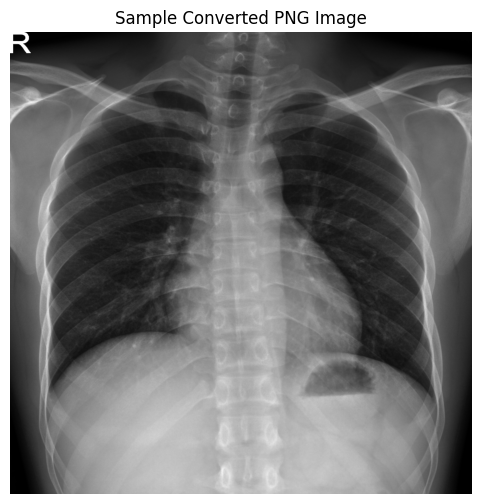

In [7]:
import cv2
import matplotlib.pyplot as plt
import os

sample_image = unique_images[0]

img_path = os.path.join(OUTPUT_IMG_PATH, sample_image + ".png")
img = cv2.imread(img_path)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Sample Converted PNG Image")
plt.axis("off")
plt.show()

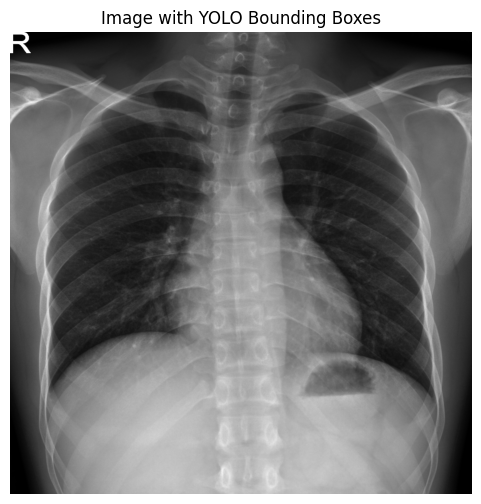

In [8]:
import numpy as np

img = cv2.imread(img_path)
h, w, _ = img.shape

label_path = os.path.join(OUTPUT_LABEL_PATH, sample_image + ".txt")

if os.path.exists(label_path):
    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        class_id, x_center, y_center, box_width, box_height = map(float, line.strip().split())

        x_center *= w
        y_center *= h
        box_width *= w
        box_height *= h

        x_min = int(x_center - box_width / 2)
        y_min = int(y_center - box_height / 2)
        x_max = int(x_center + box_width / 2)
        y_max = int(y_center + box_height / 2)

        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Image with YOLO Bounding Boxes")
plt.axis("off")
plt.show()